# Comparación interpretable vs. no interpretable

Notebook aparte de `training.ipynb` (no lo modifica). Reúne métricas de comparación entre
el modelo entrenado con la penalización de interpretabilidad y el modelo base:

1. **CKA entre la salida del MLP del último bloque**, comparando los dos modelos completos.
2. **CKA entre cada cabeza de atención**, bloque a bloque, comparando las 4 cabezas del
   modelo interpretable contra las 4 del modelo no interpretable — visualizado como una
   cuadrícula de calor por bloque.

Ambas usan [CKA lineal (Kornblith et al., 2019)](https://arxiv.org/abs/1905.00414), ya
implementada en `modules/cka.py`.

**Nota metodológica:** CKA compara la geometría de las representaciones salvo rotación y
escala isotrópica. Dos modelos entrenados por separado (distinta inicialización, sin
ninguna restricción de simetría entre ellos) no tienen por qué alinear sus neuronas ni sus
cabezas de la misma forma — un valor bajo entre, por ejemplo, la cabeza I-2 y NI-1 no
implica que una de las dos "funcione mal"; es una limitación conocida de comparar redes
independientes con esta métrica. Vale la pena tenerlo en cuenta al interpretar los
números de abajo.

In [ ]:
import json
import sys
from pathlib import Path

import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# notebooks/ vive un nivel bajo la raíz del proyecto, igual que experimentation/
project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

from modules.model import ViTForClassfication
from modules.cka import linear_cka

torch.manual_seed(0)
device = torch.device("cpu")  # el modelo es diminuto (hidden_size=48) — no hace falta GPU/MPS aquí


## 1. Cargar los dos modelos

Hay varios checkpoints sueltos en `experimentation/` (`vit_final_CIFAR10_*.pt`) y algunos
pares completos en `experimentation/experiments/<nombre>/` (pesos + `config.json` +
`metrics.json` juntos, guardados por `save_experiment`). Uso estos dos porque son el único
par con `config.json` idéntico y accuracy comparable (0.538 vs. 0.5485) — si quieres comparar
otro par de corridas, solo cambia las dos rutas de abajo.

In [ ]:
EXPERIMENTS_DIR = project_root / "experimentation" / "experiments"

EXP_NON_INTERPRETABLE = EXPERIMENTS_DIR / "vit-with-10-epochs-CIFAR10"
EXP_INTERPRETABLE = EXPERIMENTS_DIR / "vit-with-10-epochs-interpretable-CIFAR10"

with open(EXP_NON_INTERPRETABLE / "config.json") as f:
    config_non_interp = json.load(f)
with open(EXP_INTERPRETABLE / "config.json") as f:
    config_interp = json.load(f)

assert config_non_interp == config_interp, (
    "Los dos checkpoints tienen arquitecturas distintas — no son comparables con CKA. "
    "Revisa qué par de experimentos estás cargando."
)
config = config_non_interp

model_non_interpretable = ViTForClassfication(config).to(device)
model_non_interpretable.load_state_dict(
    torch.load(EXP_NON_INTERPRETABLE / "model_final.pt", map_location=device)
)
model_non_interpretable.eval()

model_interpretable = ViTForClassfication(config).to(device)
model_interpretable.load_state_dict(
    torch.load(EXP_INTERPRETABLE / "model_final.pt", map_location=device)
)
model_interpretable.eval()

print("Modelos cargados. num_hidden_layers =", config["num_hidden_layers"],
      "| num_attention_heads =", config["num_attention_heads"])


Modelos cargados. num_hidden_layers = 4 | num_attention_heads = 4


## 2. Cargar un batch de ejemplos

Reutilizo el CIFAR-10 de test que ya está descargado en `experimentation/data` (mismo
`test_transform` que en el entrenamiento) para no volver a descargar nada. 15 ejemplos,
semilla fija para que la comparación sea reproducible.

In [ ]:
from modules.datasets import CIFAR10Dataset

# Solo para reutilizar sus transforms/clases — no llama a get_loaders() porque esa
# función asume la ruta relativa "./data" y volvería a descargar el dataset.
_dataset_meta = CIFAR10Dataset()

N_SAMPLES = 15
testset = torchvision.datasets.CIFAR10(
    root=str(project_root / "experimentation" / "data"),
    train=False,
    download=False,
    transform=_dataset_meta.test_transform,
)

indices = torch.randperm(len(testset))[:N_SAMPLES].tolist()
batch = torch.stack([testset[i][0] for i in indices]).to(device)
labels = torch.tensor([testset[i][1] for i in indices])

print("Batch:", batch.shape, "| clases en el batch:",
      [_dataset_meta.classes[l] for l in labels.tolist()])


Batch: torch.Size([15, 3, 32, 32]) | clases en el batch: ['dog', 'deer', 'horse', 'bird', 'deer', 'ship', 'ship', 'deer', 'car', 'dog', 'cat', 'truck', 'frog', 'deer', 'truck']


## 3. CKA en la última capa del MLP

Un forward hook sobre `blocks[-1].mlp` de cada modelo, con el mismo batch, y CKA lineal
entre las dos activaciones (aplanando batch × posiciones de secuencia como los "ejemplos"
de CKA, igual que en Kornblith et al.).

In [ ]:
mlp_activations = {}

def _make_mlp_hook(name):
    def hook(module, inputs, output):
        mlp_activations[name] = output.detach()
    return hook

handle_non_interp = model_non_interpretable.encoder.blocks[-1].mlp.register_forward_hook(
    _make_mlp_hook("non_interpretable")
)
handle_interp = model_interpretable.encoder.blocks[-1].mlp.register_forward_hook(
    _make_mlp_hook("interpretable")
)

with torch.no_grad():
    model_non_interpretable(batch, output_attentions=False)
    model_interpretable(batch, output_attentions=False)

handle_non_interp.remove()
handle_interp.remove()

act_non_interp = mlp_activations["non_interpretable"].reshape(-1, config["hidden_size"])
act_interp = mlp_activations["interpretable"].reshape(-1, config["hidden_size"])

cka_mlp = linear_cka(act_non_interp, act_interp).item()

print(f"CKA(MLP último bloque, no-interpretable vs. interpretable) = {cka_mlp:.4f}")
print(f"({act_non_interp.shape[0]} posiciones x {act_non_interp.shape[1]} unidades ocultas por modelo)")


CKA(MLP último bloque, no-interpretable vs. interpretable) = 0.0872
(975 posiciones x 48 unidades ocultas por modelo)


## 4. CKA entre cabezas de atención, bloque a bloque

Un forward hook por cada `AttentionHead` (hay `num_attention_heads` por bloque, en los
4 bloques, en cada modelo) que captura su `attention_output` — la salida real de la
cabeza `softmax(QKᵀ)·V`, no los pesos. Con el mismo batch de arriba, para cada bloque
armo la matriz 4×4 de CKA entre las 4 cabezas del modelo interpretable (filas) y las
4 del no interpretable (columnas).

In [ ]:
head_outputs_non_interp = {}
head_outputs_interp = {}

def _make_head_hook(store, block_idx, head_idx):
    def hook(module, inputs, output):
        attention_output, _attention_probs = output
        store[(block_idx, head_idx)] = attention_output.detach()
    return hook

handles = []
for block_idx, block in enumerate(model_non_interpretable.encoder.blocks):
    for head_idx, head in enumerate(block.attention.heads):
        handles.append(head.register_forward_hook(
            _make_head_hook(head_outputs_non_interp, block_idx, head_idx)
        ))

for block_idx, block in enumerate(model_interpretable.encoder.blocks):
    for head_idx, head in enumerate(block.attention.heads):
        handles.append(head.register_forward_hook(
            _make_head_hook(head_outputs_interp, block_idx, head_idx)
        ))

with torch.no_grad():
    model_non_interpretable(batch, output_attentions=False)
    model_interpretable(batch, output_attentions=False)

for h in handles:
    h.remove()

num_blocks = config["num_hidden_layers"]
num_heads = config["num_attention_heads"]

cka_matrices = torch.zeros(num_blocks, num_heads, num_heads)
for b in range(num_blocks):
    for i in range(num_heads):  # cabeza interpretable
        x_i = head_outputs_interp[(b, i)].reshape(-1, config["hidden_size"] // num_heads)
        for j in range(num_heads):  # cabeza no interpretable
            x_j = head_outputs_non_interp[(b, j)].reshape(-1, config["hidden_size"] // num_heads)
            cka_matrices[b, i, j] = linear_cka(x_i, x_j)

cka_matrices = cka_matrices.numpy()
print("cka_matrices shape:", cka_matrices.shape, "(bloques, cabeza interpretable, cabeza no interpretable)")


cka_matrices shape: (4, 4, 4) (bloques, cabeza interpretable, cabeza no interpretable)


## 5. Visualización — cuadrícula de calor por bloque

Paleta secuencial (un solo hue, claro→oscuro) del skill de dataviz — es el encoding
correcto para "comparar magnitud en una cuadrícula". Valor de CKA anotado en cada celda,
mismo estilo que la matriz de confusión que ya usan en `training.ipynb`.

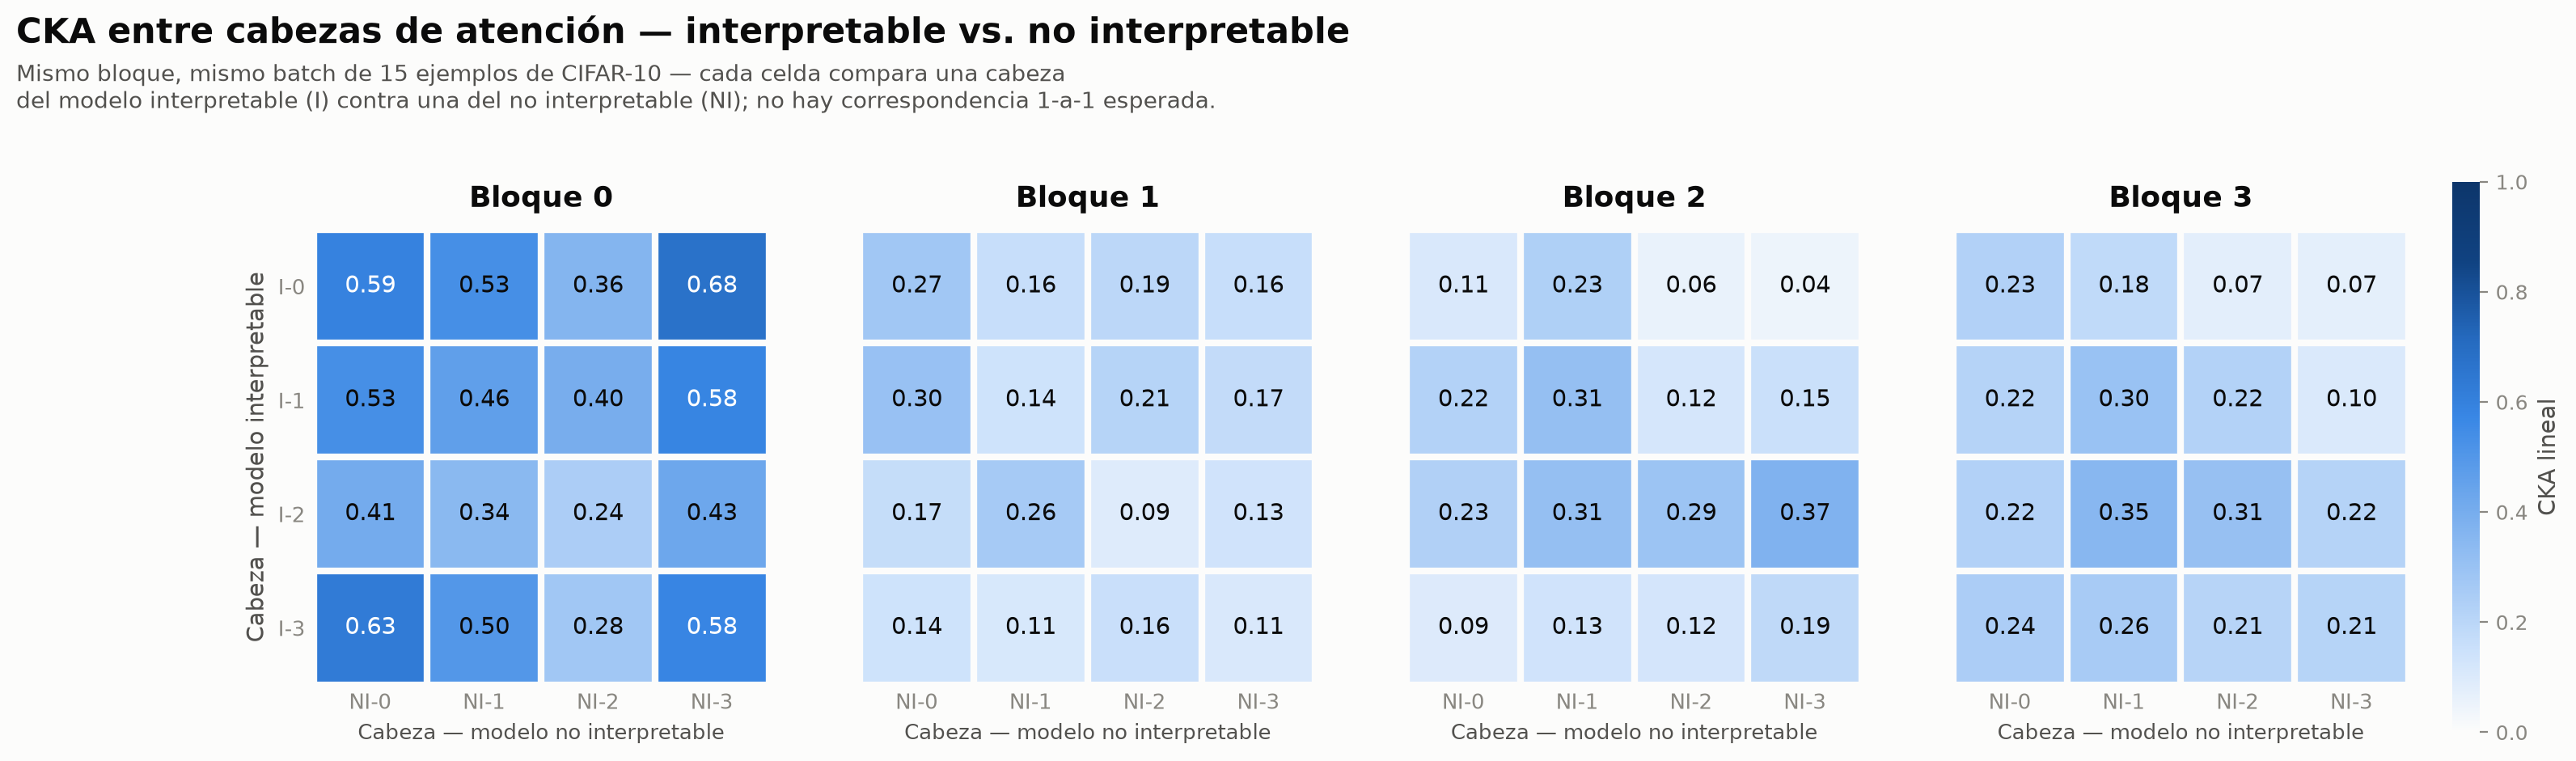

In [ ]:
SURFACE, INK, INK_SEC, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]

# Rampa secuencial validada (references/palette.md del skill de dataviz), azul claro->oscuro
seq_steps = ["#fcfcfb", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#104281", "#0d366b"]
cmap = mcolors.LinearSegmentedColormap.from_list("seq_blue", seq_steps)

fig, axes = plt.subplots(1, num_blocks, figsize=(4 * num_blocks + 1.5, 5.2), dpi=200)
fig.patch.set_facecolor(SURFACE)

im = None
for b in range(num_blocks):
    ax = axes[b]
    ax.set_facecolor(SURFACE)
    mat = cka_matrices[b]
    im = ax.imshow(mat, cmap=cmap, vmin=0.0, vmax=1.0)

    for i in range(num_heads):
        for j in range(num_heads):
            val = mat[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10.5,
                    color="white" if val > 0.55 else INK)

    ax.set_xticks(range(num_heads))
    ax.set_yticks(range(num_heads))
    ax.set_xticklabels([f"NI-{k}" for k in range(num_heads)], color=INK_MUTED, fontsize=9.5)
    if b == 0:
        ax.set_yticklabels([f"I-{k}" for k in range(num_heads)], color=INK_MUTED, fontsize=9.5)
        ax.set_ylabel("Cabeza — modelo interpretable", color=INK_SEC, fontsize=10.5)
    else:
        ax.set_yticklabels([])
    ax.set_xlabel("Cabeza — modelo no interpretable", color=INK_SEC, fontsize=9.5)
    ax.set_title(f"Bloque {b}", color=INK, fontsize=13, fontweight="bold", pad=10)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(np.arange(-0.5, num_heads, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, num_heads, 1), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=3)
    ax.tick_params(which="minor", length=0)
    ax.tick_params(which="major", length=0)

cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, shrink=0.85)
cbar.set_label("CKA lineal", color=INK_SEC, fontsize=10.5)
cbar.ax.tick_params(colors=INK_MUTED, labelsize=9)
cbar.outline.set_visible(False)

fig.suptitle("CKA entre cabezas de atención — interpretable vs. no interpretable",
             color=INK, fontsize=15.5, fontweight="bold", x=0.02, ha="left", y=1.02)
fig.text(0.02, 0.965,
         f"Mismo bloque, mismo batch de {N_SAMPLES} ejemplos de CIFAR-10 — cada celda compara una cabeza\n"
         "del modelo interpretable (I) contra una del no interpretable (NI); no hay correspondencia 1-a-1 esperada.",
         color=INK_SEC, fontsize=10, ha="left", va="top")

fig.savefig(Path.cwd() / "cka_heads_heatmap.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()


## Resumen

- **CKA(MLP, último bloque)**: un solo número (celda de arriba) — cobra más sentido
  comparado contra otras corridas o contra la CKA de las cabezas, no tanto como valor
  absoluto aislado.
- **CKA por cabeza, bloque a bloque**: la cuadrícula de arriba, guardada también como
  `cka_heads_heatmap.png` junto a este notebook para usar directo en el póster.